### This notebook loads the f-contrast maps from the RETROICOR regressors and plot them

In [17]:
import numpy as np
import nibabel as nib
import nitools as nt
import nilearn.image as image
from nilearn import plotting
import matplotlib.pyplot as plt
import os

In [ ]:
fmap_path = '/cifs/diedrichsen/data/Cerebellum/Social/data/GLM_physio/glm_task0_retro1_hrcrf0_hr0'
anat_path = '/cifs/diedrichsen/data/Cerebellum/Social/data/anatomicals/'
subj_list = ['sub-05', 'sub-07', 'sub-08', 'sub-09', 'sub-11', 'sub-12', 'sub-13', 'sub-16', 
'sub-17', 'sub-18', 'sub-19', 'sub-20', 'sub-21', 'sub-22', 'sub-25', 'sub-27']

#### F-contrast maps of RETROICOR in individual space

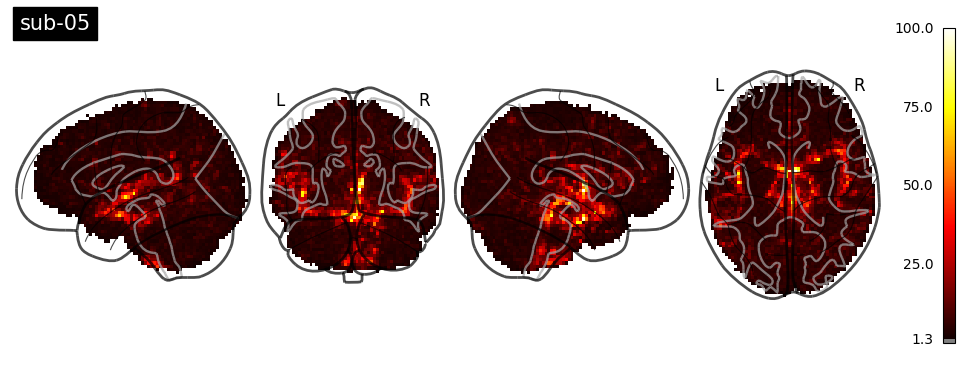

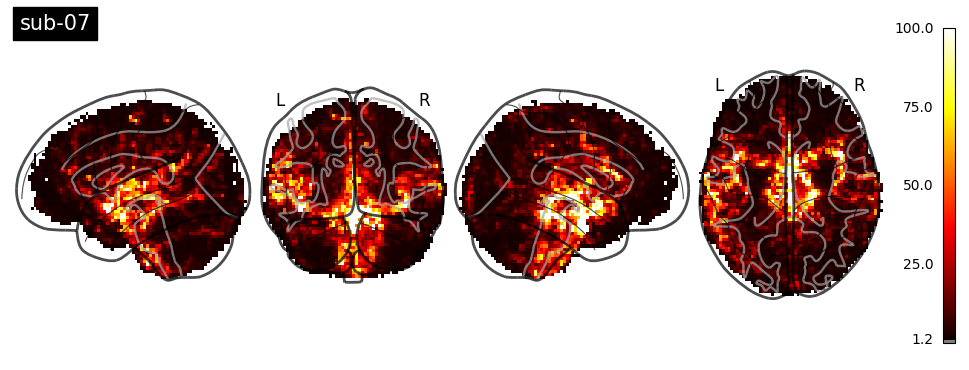

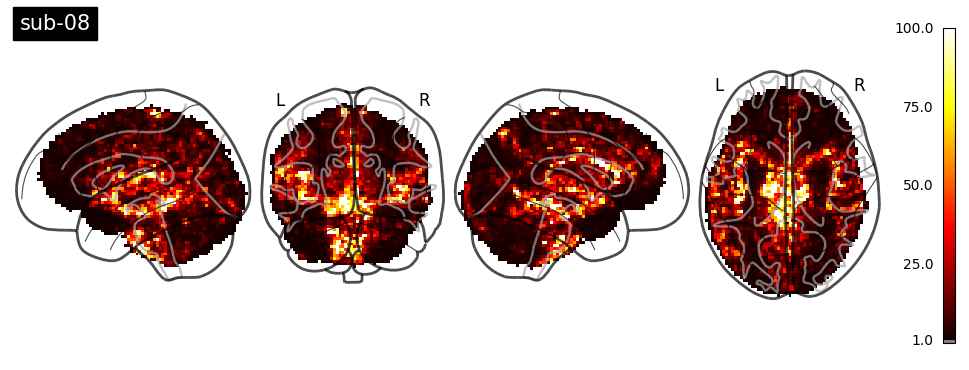

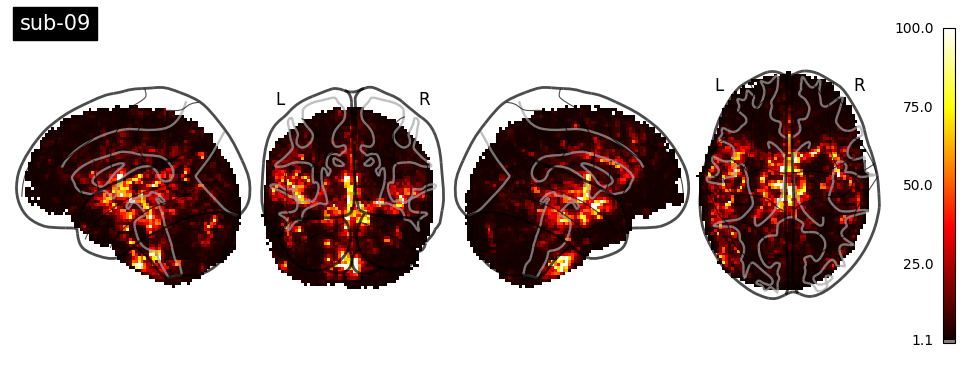

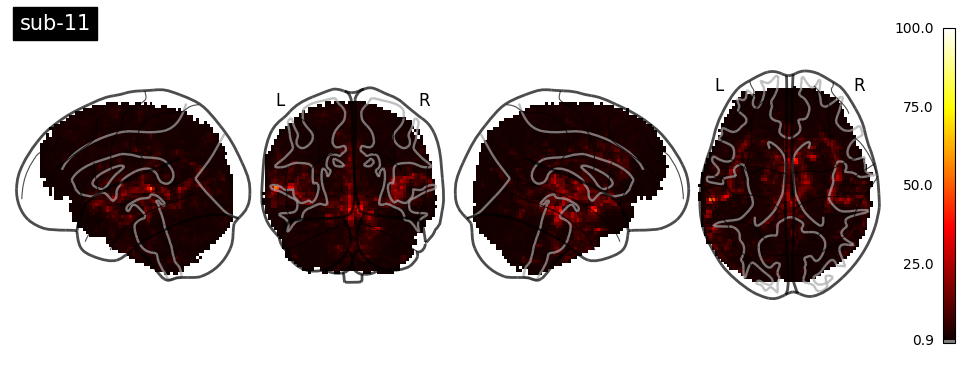

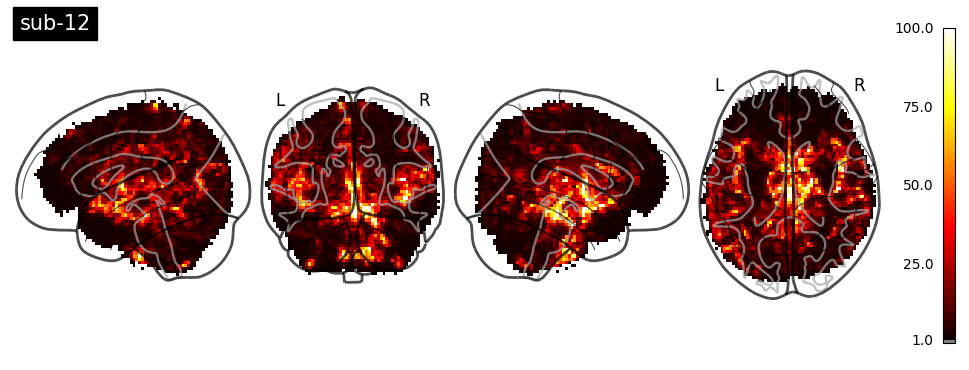

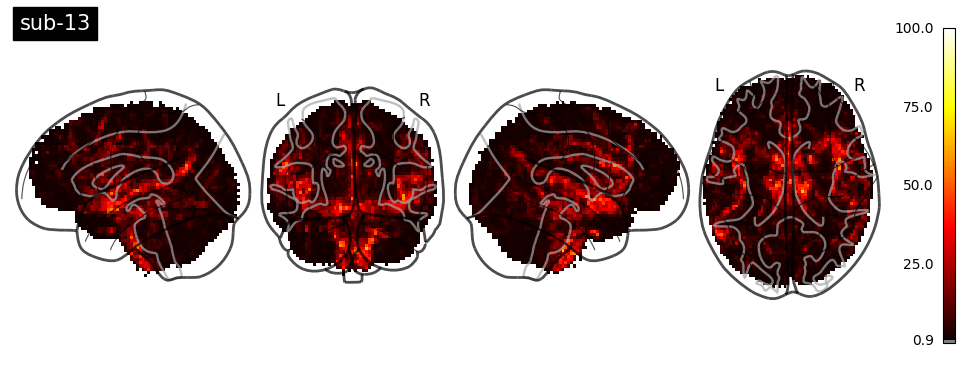

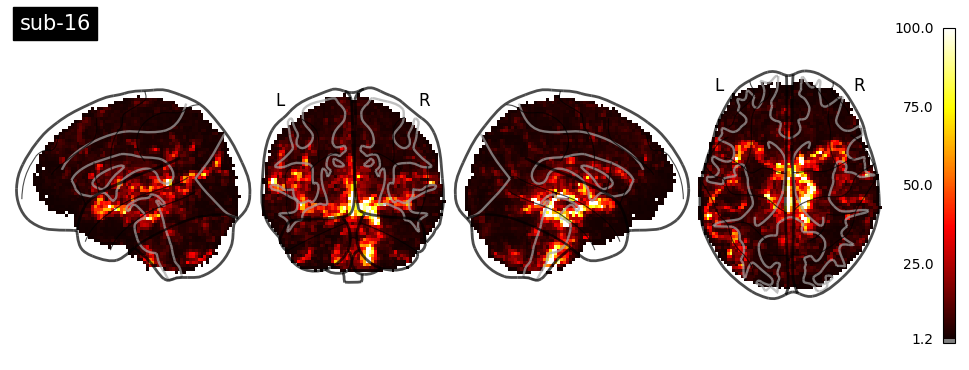

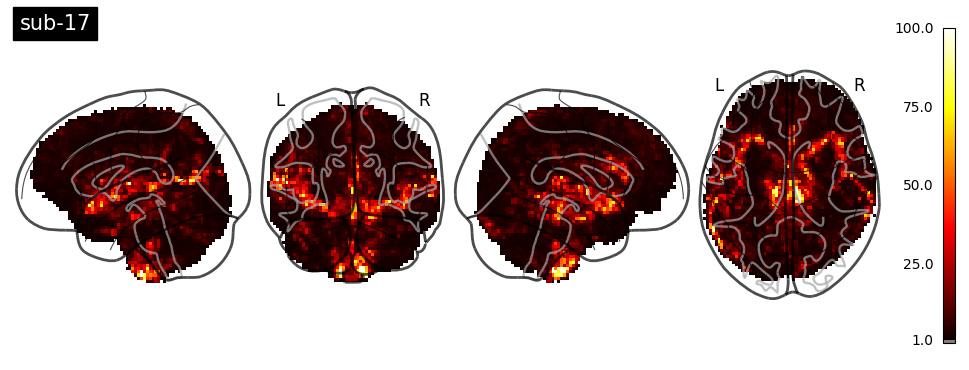

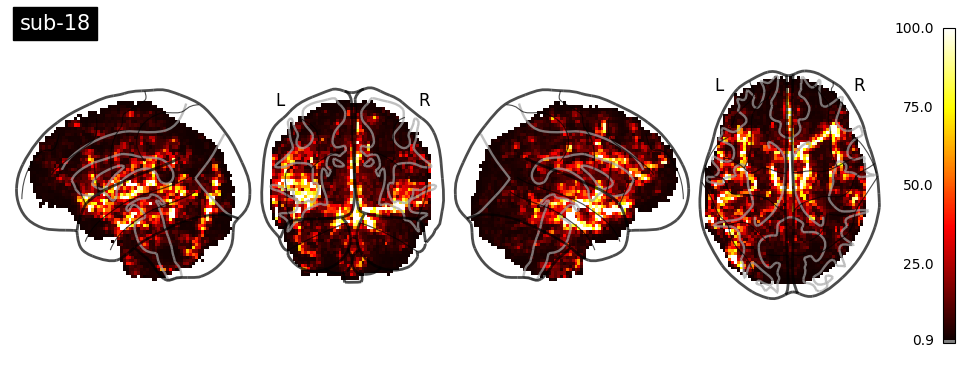

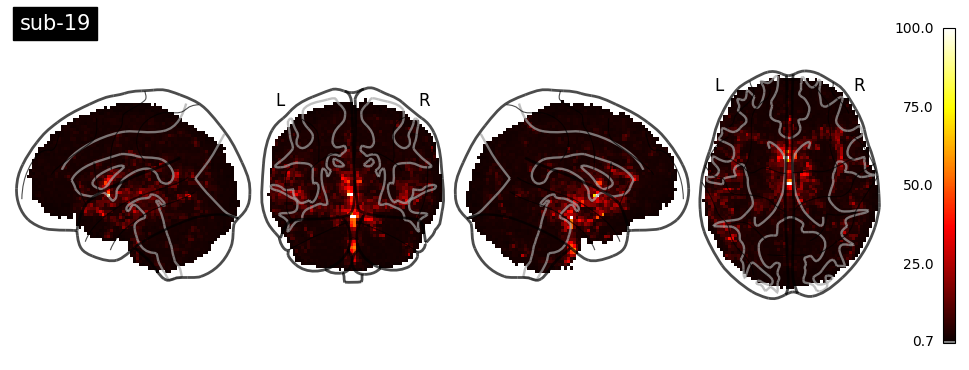

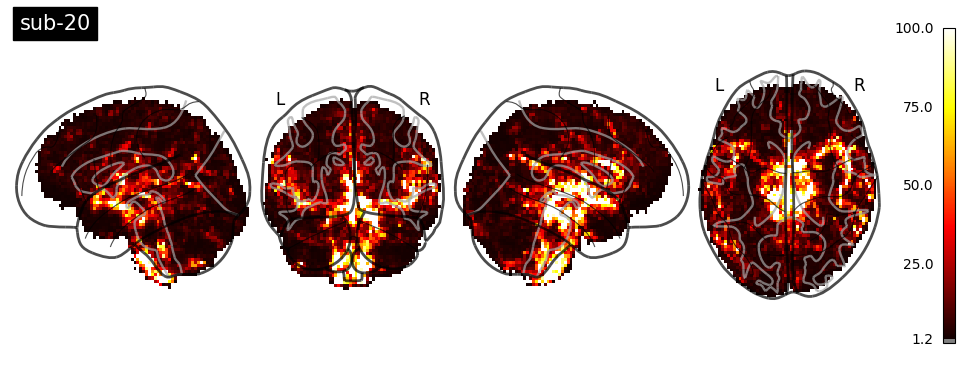

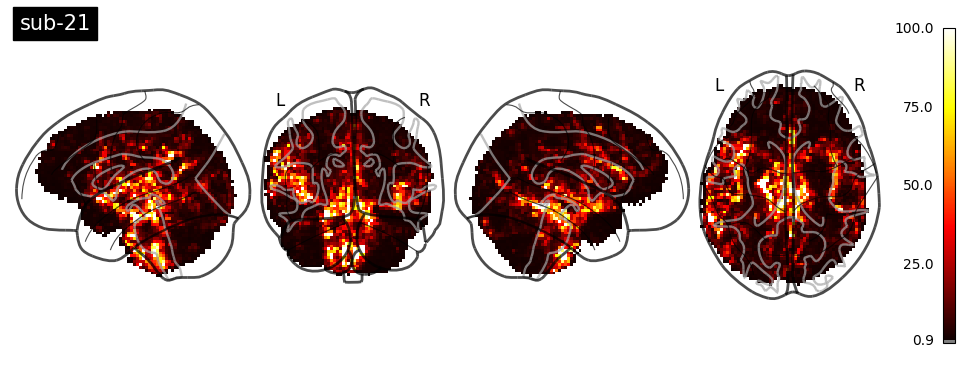

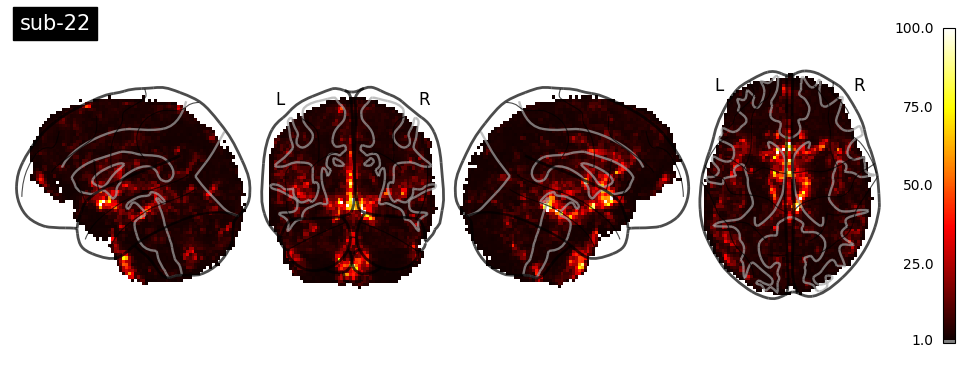

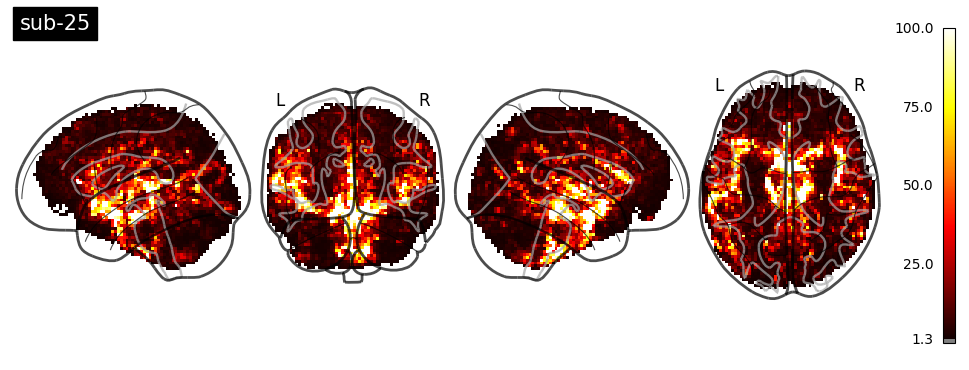

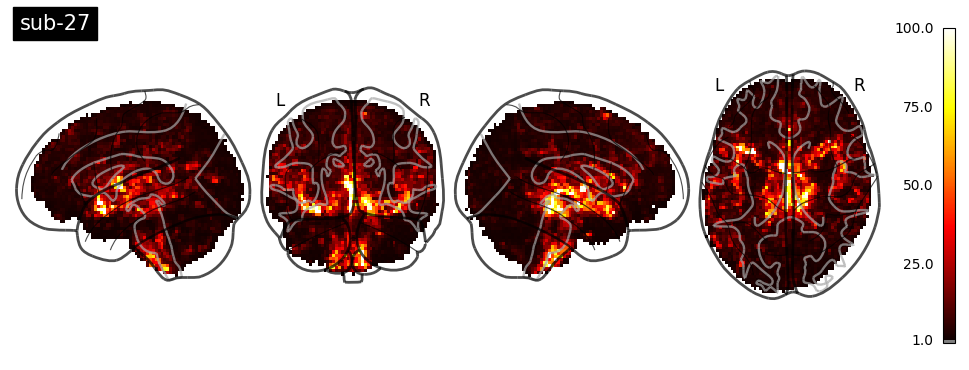

In [ ]:
for sub in subj_list:
    file_path = f'{fmap_path}/{sub}/spmF_0001.nii'
    plotting.plot_glass_brain(file_path, display_mode='lyrz', colorbar=True, cmap='hot', cbar_tick_format="%.1f",
                            plot_abs=False, title=f'{sub}', vmin=0, vmax=100)
    plotting.show()

### Transform f-maps from individual space to MNI

In [ ]:
for sub in subj_list:
    # file paths
    con_file = f'{fmap_path}/{sub}/spmF_0001.nii'
    mask_file = f'{fmap_path}/{sub}/mask.nii'
    def_file = f'{anat_path}/{sub}/y_anatomical.nii'

    # load files
    con_img = nib.load(con_file)
    mask_img = nib.load(mask_file)
    mask_data = mask_img.get_fdata()
    def_img = nib.load(def_file)

    # smooth image
    smoothed_img = image.smooth_img(con_img, fwhm=4)
    smoothed_data = smoothed_img.get_fdata()

    # apply mask
    masked_data = smoothed_data * (mask_data > 0)
    masked_img = nib.Nifti1Image(masked_data, con_img.affine, con_img.header)

    wcon_file = nt.deform_image(masked_img, def_img, interpolation=1)
    wcon_path = os.path.join(fmap_path, f'{sub}/wspmF_0001.nii')
    nib.save(wcon_file, wcon_path)

In [20]:
# average wspmF files
fmap_list = []
for sub in subj_list:
    file_path = f'{fmap_path}/{sub}/wspmF_0001.nii'
    fmap_img = nib.load(file_path)
    fmap_list.append(fmap_img.get_fdata())

mean_fmap_data = np.nanmean(fmap_list, axis=0)
mean_fmap_img = nib.Nifti1Image(mean_fmap_data, fmap_img.affine, fmap_img.header)

nib.save(mean_fmap_img, f'{fmap_path}/group/mean_wspmF_0001.nii')

/tmp/ipykernel_449572/4094360417.py:8: RuntimeWarning: Mean of empty slice
  mean_fmap_data = np.nanmean(fmap_list, axis=0)


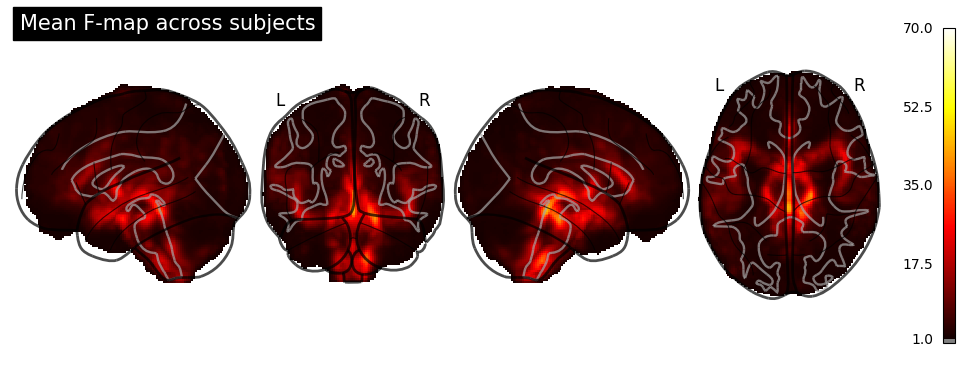

In [31]:
file_path = f'{fmap_path}/group/mean_wspmF_0001.nii'
plotting.plot_glass_brain(file_path, display_mode='lyrz', colorbar=True, cmap='hot', cbar_tick_format="%.1f",
                        plot_abs=False, title='Mean F-map across subjects', vmin=0, vmax=70, threshold=1)
plotting.show()